# **Dataset**

In [ ]:
!pip install datasets rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9cb0f0e65e8f08936817d9042c4af6d8f53dd03d3a43ba5073124c25a176ff22
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
from datasets import load_dataset

dataset = load_dataset("therapara/summary-of-news-articles")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/539 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/160M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/39.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44972 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5622 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5622 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['document', 'summary'],
        num_rows: 44972
    })
    validation: Dataset({
        features: ['document', 'summary'],
        num_rows: 5622
    })
    test: Dataset({
        features: ['document', 'summary'],
        num_rows: 5622
    })
})


In [ ]:
sample = dataset['train'][0]

print("=" * 60)
print("ARTICLE:")
print(sample['document'][:1000])  # first 1000 chars
print("\nSUMMARY:")
print(sample['summary'])

ARTICLE:
National Archives 
 
 Yes, it’s that time again, folks. It’s the first Friday of the month, when for one ever-so-brief moment the interests of Wall Street, Washington and Main Street are all aligned on one thing: Jobs. 
 
 A fresh update on the U.S. employment situation for January hits the wires at 8:30 a.m. New York time offering one of the most important snapshots on how the economy fared during the previous month. Expectations are for 203,000 new jobs to be created, according to economists polled by Dow Jones Newswires, compared to 227,000 jobs added in February. The unemployment rate is expected to hold steady at 8.3%. 
 
 Here at MarketBeat HQ, we’ll be offering color commentary before and after the data crosses the wires. Feel free to weigh-in yourself, via the comments section. And while you’re here, why don’t you sign up to follow us on Twitter. 
 
 Enjoy the show. ||||| Employers pulled back sharply on hiring last month, a reminder that the U.S. economy may not be gr

In [ ]:
import numpy as np

train_data = dataset['train']

article_lengths = [len(row['document'].split()) for row in train_data]
summary_lengths = [len(row['summary'].split()) for row in train_data]

print("📄 ARTICLE STATS (words):")
print(f"  Average  : {np.mean(article_lengths):.0f}")
print(f"  Max      : {np.max(article_lengths)}")
print(f"  Min      : {np.min(article_lengths)}")
print(f"  Median   : {np.median(article_lengths):.0f}")

print("\n📝 SUMMARY STATS (words):")
print(f"  Average  : {np.mean(summary_lengths):.0f}")
print(f"  Max      : {np.max(summary_lengths)}")
print(f"  Min      : {np.min(summary_lengths)}")
print(f"  Median   : {np.median(summary_lengths):.0f}")

print(f"\n📊 Average compression ratio: {np.mean(article_lengths) / np.mean(summary_lengths):.1f}x")

📄 ARTICLE STATS (words):
  Average  : 1794
  Max      : 449621
  Min      : 0
  Median   : 1326

📝 SUMMARY STATS (words):
  Average  : 218
  Max      : 973
  Min      : 34
  Median   : 221

📊 Average compression ratio: 8.2x


### The article's/summary's word length will be handled later on

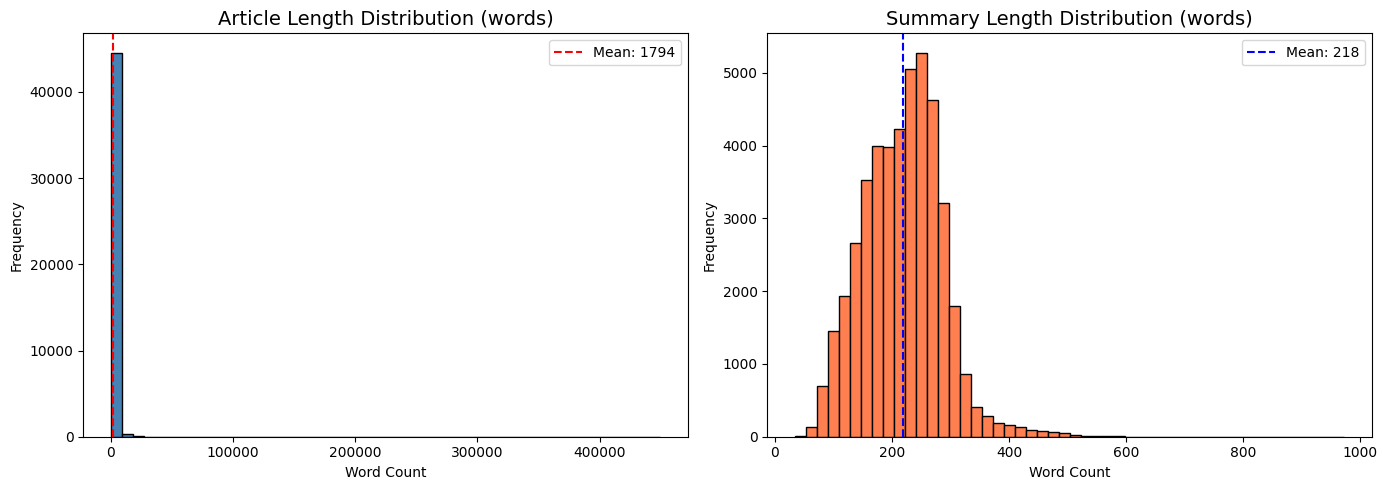

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Article lengths
axes[0].hist(article_lengths, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Article Length Distribution (words)', fontsize=14)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(article_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(article_lengths):.0f}')
axes[0].legend()

# Summary lengths
axes[1].hist(summary_lengths, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Summary Length Distribution (words)', fontsize=14)
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(summary_lengths), color='blue', linestyle='--', label=f'Mean: {np.mean(summary_lengths):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150)
plt.show()

#### Checking null values

In [ ]:
def check_nulls(split_name):
    split = dataset[split_name]
    empty_docs     = sum(1 for row in split if not row['document'].strip())
    empty_summaries = sum(1 for row in split if not row['summary'].strip())
    print(f"[{split_name}] Empty articles: {empty_docs} | Empty summaries: {empty_summaries}")

check_nulls('train')
check_nulls('validation')
check_nulls('test')

[train] Empty articles: 8 | Empty summaries: 0
[validation] Empty articles: 1 | Empty summaries: 0
[test] Empty articles: 1 | Empty summaries: 0


In [ ]:
def remove_empty(example):
    return example['document'].strip() != ''

dataset = dataset.filter(remove_empty)

# Confirm they're gone
print("✅ After cleaning:")
print(f"  Train      : {len(dataset['train'])} rows")
print(f"  Validation : {len(dataset['validation'])} rows")
print(f"  Test       : {len(dataset['test'])} rows")

Filter:   0%|          | 0/44972 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5622 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5622 [00:00<?, ? examples/s]

✅ After cleaning:
  Train      : 44964 rows
  Validation : 5621 rows
  Test       : 5621 rows


Re-checking after removing null values

In [ ]:
def check_nulls(split_name):
    split = dataset[split_name]
    empty_docs     = sum(1 for row in split if not row['document'].strip())
    empty_summaries = sum(1 for row in split if not row['summary'].strip())
    print(f"[{split_name}] Empty articles: {empty_docs} | Empty summaries: {empty_summaries}")

check_nulls('train')
check_nulls('validation')
check_nulls('test')

[train] Empty articles: 0 | Empty summaries: 0
[validation] Empty articles: 0 | Empty summaries: 0
[test] Empty articles: 0 | Empty summaries: 0


In [ ]:
for i in range(3):
    row = dataset['train'][i]
    print(f"\n{'='*60}")
    print(f"Example {i+1}")
    print(f"{'='*60}")
    print(f"ARTICLE (first 300 chars):\n{row['document'][:300]}...")
    print(f"\nSUMMARY:\n{row['summary']}")


Example 1
ARTICLE (first 300 chars):
National Archives 
 
 Yes, it’s that time again, folks. It’s the first Friday of the month, when for one ever-so-brief moment the interests of Wall Street, Washington and Main Street are all aligned on one thing: Jobs. 
 
 A fresh update on the U.S. employment situation for January hits the wires at...

SUMMARY:
– The unemployment rate dropped to 8.2% last month, but the economy only added 120,000 jobs, when 203,000 new jobs had been predicted, according to today's jobs report. Reaction on the Wall Street Journal's MarketBeat Blog was swift: "Woah!!! Bad number." The unemployment rate, however, is better news; it had been expected to hold steady at 8.3%. But the AP notes that the dip is mostly due to more Americans giving up on seeking employment.

Example 2
ARTICLE (first 300 chars):
LOS ANGELES (AP) — In her first interview since the NBA banned her estranged husband, Shelly Sterling says she will fight to keep her share of the Los Angeles Clipper

# **Pre-Processing**

max article length is 400 since our average length is 1794, articles will be truncated

same goes for summaries where their average length is shorter which is 218, so we will use a 100 max summary length

In [ ]:
import re
import numpy as np
from collections import Counter
from datasets import load_dataset
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

MAX_ARTICLE_LEN  = 400   # covers ~median article well
MAX_SUMMARY_LEN  = 100   # covers ~median summary well
VOCAB_SIZE       = 30000 # top 30k most frequent words

In [ ]:
def clean_text(text):
    text = text.lower()                            # lowercase
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags
    text = re.sub(r'\(ap\)|\(reuters\)', '', text) # remove wire service tags
    text = re.sub(r'[^a-z0-9\s\.\,\!\?]', '', text) # keep letters, digits, basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # collapse extra whitespace
    return text

def clean_summary(text):
    text = clean_text(text)
    text = 'sostok ' + text + ' eostok'            # add start/end tokens
    return text

In [ ]:
sample = dataset['train'][0]
print("Sample Article with no cleaning")
print(dataset['train'][0]['document'][:300])
print("\nCLEANED ARTICLE:")
print(clean_text(sample['document'])[:300])
print("\nCLEANED SUMMARY:")
print(clean_summary(sample['summary']))

Sample Article with no cleaning
National Archives 
 
 Yes, it’s that time again, folks. It’s the first Friday of the month, when for one ever-so-brief moment the interests of Wall Street, Washington and Main Street are all aligned on one thing: Jobs. 
 
 A fresh update on the U.S. employment situation for January hits the wires at

CLEANED ARTICLE:
national archives yes, its that time again, folks. its the first friday of the month, when for one eversobrief moment the interests of wall street, washington and main street are all aligned on one thing jobs. a fresh update on the u.s. employment situation for january hits the wires at 830 a.m. new

CLEANED SUMMARY:
sostok the unemployment rate dropped to 8.2 last month, but the economy only added 120,000 jobs, when 203,000 new jobs had been predicted, according to todays jobs report. reaction on the wall street journals marketbeat blog was swift woah!!! bad number. the unemployment rate, however, is better news it had been expected to hold

In [ ]:
print("Cleaning dataset...")

train_articles  = [clean_text(row['document']) for row in dataset['train']]
train_summaries = [clean_summary(row['summary']) for row in dataset['train']]

val_articles    = [clean_text(row['document']) for row in dataset['validation']]
val_summaries   = [clean_summary(row['summary']) for row in dataset['validation']]

test_articles   = [clean_text(row['document']) for row in dataset['test']]
test_summaries  = [clean_summary(row['summary']) for row in dataset['test']]

print(f"Train    : {len(train_articles)} samples")
print(f"Val      : {len(val_articles)} samples")
print(f"Test     : {len(test_articles)} samples")

Cleaning dataset...
Train    : 44964 samples
Val      : 5621 samples
Test     : 5621 samples


Remove samples where article is unreasonably long (outliers like 449k words)

In [ ]:
MAX_RAW_WORDS = 5000

def filter_by_length(articles, summaries):
    filtered_a, filtered_s = [], []
    for a, s in zip(articles, summaries):
        if len(a.split()) <= MAX_RAW_WORDS:
            filtered_a.append(a)
            filtered_s.append(s)
    return filtered_a, filtered_s

train_articles, train_summaries = filter_by_length(train_articles, train_summaries)
val_articles,   val_summaries   = filter_by_length(val_articles,   val_summaries)
test_articles,  test_summaries  = filter_by_length(test_articles,  test_summaries)

print(f"✅ After outlier removal:")
print(f"   Train : {len(train_articles)}")
print(f"   Val   : {len(val_articles)}")
print(f"   Test  : {len(test_articles)}")

✅ After outlier removal:
   Train : 43125
   Val   : 5406
   Test  : 5391


In [ ]:
print("Building vocabulary...")

article_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>', filters='')
article_tokenizer.fit_on_texts(train_articles)

summary_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>', filters='')
summary_tokenizer.fit_on_texts(train_summaries)

print(f"✅ Article vocabulary size : {len(article_tokenizer.word_index)}")
print(f"✅ Summary vocabulary size : {len(summary_tokenizer.word_index)}")

print(f"\n   'sostok' index : {summary_tokenizer.word_index.get('sostok')}")
print(f"   'eostok' index : {summary_tokenizer.word_index.get('eostok')}")

Building vocabulary...
✅ Article vocabulary size : 783488
✅ Summary vocabulary size : 248064

   'sostok' index : 20
   'eostok' index : 21


Confirm the effective vocab being used is 30k, not 783k


In [ ]:
print(f"Configured VOCAB_SIZE       : {VOCAB_SIZE}")
print(f"Effective article vocab     : {min(VOCAB_SIZE, len(article_tokenizer.word_index))}")
print(f"Effective summary vocab     : {min(VOCAB_SIZE, len(summary_tokenizer.word_index))}")

start_token = summary_tokenizer.word_index['sostok']
end_token   = summary_tokenizer.word_index['eostok']

print(f"\nStart token index (sostok)  : {start_token}")
print(f"End token index   (eostok)  : {end_token}")

Configured VOCAB_SIZE       : 30000
Effective article vocab     : 30000
Effective summary vocab     : 30000

Start token index (sostok)  : 20
End token index   (eostok)  : 21


In [ ]:
print("Converting to sequences...")

# Encode
x_train = article_tokenizer.texts_to_sequences(train_articles)
x_val   = article_tokenizer.texts_to_sequences(val_articles)
x_test  = article_tokenizer.texts_to_sequences(test_articles)

y_train = summary_tokenizer.texts_to_sequences(train_summaries)
y_val   = summary_tokenizer.texts_to_sequences(val_summaries)
y_test  = summary_tokenizer.texts_to_sequences(test_summaries)

# Pad (post = pad at the end)
x_train = pad_sequences(x_train, maxlen=MAX_ARTICLE_LEN, padding='post', truncating='post')
x_val   = pad_sequences(x_val,   maxlen=MAX_ARTICLE_LEN, padding='post', truncating='post')
x_test  = pad_sequences(x_test,  maxlen=MAX_ARTICLE_LEN, padding='post', truncating='post')

y_train = pad_sequences(y_train, maxlen=MAX_SUMMARY_LEN, padding='post', truncating='post')
y_val   = pad_sequences(y_val,   maxlen=MAX_SUMMARY_LEN, padding='post', truncating='post')
y_test  = pad_sequences(y_test,  maxlen=MAX_SUMMARY_LEN, padding='post', truncating='post')

print(f"✅ x_train shape : {x_train.shape}")
print(f"✅ y_train shape : {y_train.shape}")
print(f"✅ x_test shape  : {x_test.shape}")
print(f"✅ y_test shape  : {y_test.shape}")

Converting to sequences...
✅ x_train shape : (43125, 400)
✅ y_train shape : (43125, 100)
✅ x_test shape  : (5391, 400)
✅ y_test shape  : (5391, 100)


In [ ]:
with open('article_tokenizer.pkl', 'wb') as f:
    pickle.dump(article_tokenizer, f)
with open('summary_tokenizer.pkl', 'wb') as f:
    pickle.dump(summary_tokenizer, f)

# Save arrays
np.save('x_train.npy', x_train)
np.save('x_val.npy',   x_val)
np.save('x_test.npy',  x_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

print("All preprocessed data saved!")

All preprocessed data saved!


### Small notes before training
* N-grams? NO — n-grams are for bag-of-words models. Seq2Seq models process sequences word by word so they implicitly learn n-gram patterns.

* Remove stop words? ABSOLUTELY NO — this is the most important one. Since we are doing abstractive summarization, the model needs to generate fluent sentences. Removing "the", "is", "a" etc. would completely destroy the grammar of generated summaries.

* POS Tagging & NER? NO — these are for information extraction tasks. Our neural models learn linguistic patterns on their own from the data.

# **RNN**

EMBEDDING_DIM is how richly each word is represented.

RNN_UNITS is how much memory the RNN has.



In [ ]:
VOCAB_SIZE      = 30000  # same as preprocessing
EMBEDDING_DIM   = 128    # each word becomes a 128-number vector
RNN_UNITS       = 256    # memory size of the RNN
MAX_ARTICLE_LEN = 400
MAX_SUMMARY_LEN = 100
BATCH_SIZE      = 64
EPOCHS          = 10

Decoder input  = summary WITHOUT the last token  → [sostok, w1, w2, ..., w99]

Decoder target = summary WITHOUT the first token → [w1,     w2, w3, ..., eostok]

This is called teacher forcing. During training, we feed the decoder the real previous word at each step (not its own prediction). It is like giving the model the answer sheet while it's learning.



In [ ]:
decoder_input_train  = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]

decoder_input_val    = y_val[:, :-1]
decoder_target_val   = y_val[:, 1:]

print(f"✅ Decoder input  shape: {decoder_input_train.shape}")
print(f"✅ Decoder target shape: {decoder_target_train.shape}")

✅ Decoder input  shape: (43125, 99)
✅ Decoder target shape: (43125, 99)


The encoder reads all 400 word-vectors one by one. After reading the last word, it produces a single state vector of 256 numbers — this is the compressed memory of the entire article.



In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
from tensorflow.keras.models import Model

# Encoder
encoder_inputs = Input(shape=(MAX_ARTICLE_LEN,), name='encoder_input')

# Embedding: converts word IDs → dense vectors
encoder_embedding = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                               mask_zero=True,
                               name='encoder_embedding')(encoder_inputs)

# SimpleRNN: reads the sequence, returns final hidden state only
encoder_outputs, encoder_state = SimpleRNN(RNN_UNITS,
                                            return_state=True,
                                            name='encoder_rnn')(encoder_embedding)

print("✅ Encoder built")
print(f"   Encoder state shape: {encoder_state.shape}")

✅ Encoder built
   Encoder state shape: (None, 256)


The decoder starts with the encoder's state as its memory. At each step it outputs a probability distribution over 30,000 words — the word with the highest probability becomes the next word in the summary.



In [ ]:
# Decoder
decoder_inputs = Input(shape=(MAX_SUMMARY_LEN - 1,), name='decoder_input')

# Embedding for summary words
decoder_embedding = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                               mask_zero=True,
                               name='decoder_embedding')(decoder_inputs)

# SimpleRNN: initialized with encoder state, returns full sequence
decoder_rnn_out, _ = SimpleRNN(RNN_UNITS,
                                return_sequences=True,
                                return_state=True,
                                name='decoder_rnn')(decoder_embedding,
                                                   initial_state=encoder_state)

# Dense: at each time step, predict the next word from full vocabulary
decoder_outputs = Dense(VOCAB_SIZE,
                         activation='softmax',
                         name='output')(decoder_rnn_out)

print("✅ Decoder built")
print(f"   Output shape: {decoder_outputs.shape}")

✅ Decoder built
   Output shape: (None, 99, 30000)


### Assemble & Compile the Full Model


sparse_categorical_crossentropy is used because our targets are integer word IDs (not one-hot encoded).

Adam optimizer adjusts learning rate automatically — best default choice for this task.



In [ ]:
rnn_model = Model(
    inputs  = [encoder_inputs, decoder_inputs],
    outputs = decoder_outputs,
    name    = 'Seq2Seq_RNN'
)

rnn_model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

rnn_model.summary()

Model: "Seq2Seq_RNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 99)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 400, 128)  │  3,840,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 400)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 99, 128)   │  3,840,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_rnn         │ [(None, 256),     │     98,560 │ encoder_embeddin… │
│ (SimpleRNN)         │ (None, 256)]      │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, 99, 256), │     98,560 │ decoder_embeddin… │
│ (SimpleRNN)         │ (None, 256)]      │            │ encoder_rnn[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 99, 30000) │  7,710,000 │ decoder_rnn[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,587,120 (59.46 MB)

 Trainable params: 15,587,120 (59.46 MB)

 Non-trainable params: 0 (0.00 B)

### Add Callbacks & Train

EarlyStopping prevents overfitting by stopping when the model stops improving on validation data.

ModelCheckpoint saves the best version so you don't lose it if training crashes.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),

    ModelCheckpoint('best_rnn_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history = rnn_model.fit(
    [x_train, decoder_input_train],
    decoder_target_train,
    validation_data=([x_val, decoder_input_val], decoder_target_val),
    batch_size = BATCH_SIZE,
    epochs     = EPOCHS,
    callbacks  = callbacks,
    verbose    = 1
)

Epoch 1/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.0598 - loss: 7.4987
Epoch 1: val_loss improved from None to 6.91443, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 143s 195ms/step - accuracy: 0.0651 - loss: 7.2662 - val_accuracy: 0.1016 - val_loss: 6.9144
Epoch 2/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1235 - loss: 6.6270
Epoch 2: val_loss improved from 6.91443 to 5.98937, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 125s 185ms/step - accuracy: 0.1383 - loss: 6.3852 - val_accuracy: 0.1610 - val_loss: 5.9894
Epoch 3/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.1656 - loss: 5.8712
Epoch 3: val_loss improved from 5.98937 to 5.70192, saving model to best_rnn_model.keras

Epoch 3: finished saving model to best_rnn_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 125s 186ms/step - accuracy: 0.169

## The RNN Training took about 30 mins

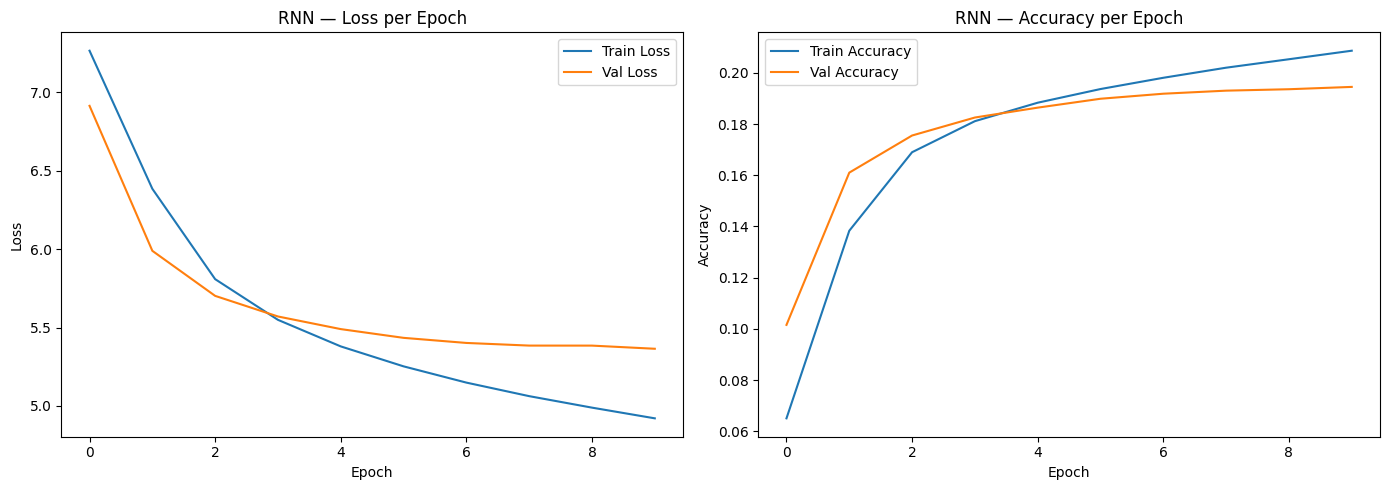

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('RNN — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('RNN — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('rnn_training_curves.png', dpi=150)
plt.show()

### Inference Model

We need separate encoder/decoder models for inference because at test time we generate word by word, not all at once

During training the decoder saw all words at once. At inference time, it generates one word at a time, feeds it back as input, and repeats until eostok appears. These two separate models allow us to do that.



In [ ]:
# ── Inference Encoder ────────────────────────────────
inference_encoder = Model(
    inputs  = encoder_inputs,
    outputs = encoder_state,
    name    = 'inference_encoder'
)

# ── Inference Decoder ────────────────────────────────
decoder_state_input = Input(shape=(RNN_UNITS,))

inf_decoder_emb = decoder_embedding  # reuse trained embedding

inf_decoder_out, inf_decoder_state = SimpleRNN(
    RNN_UNITS,
    return_sequences=True,
    return_state=True,
    name='decoder_rnn'
)(inf_decoder_emb, initial_state=decoder_state_input)

inf_decoder_dense_out = Dense(VOCAB_SIZE, activation='softmax', name='output')(inf_decoder_out)

inference_decoder = Model(
    inputs  = [decoder_inputs, decoder_state_input],
    outputs = [inf_decoder_dense_out, inf_decoder_state],
    name    = 'inference_decoder'
)

print("✅ Inference models ready")

✅ Inference models ready


In [ ]:
# Reverse index: number → word
reverse_summary_index  = {v: k for k, v in summary_tokenizer.word_index.items()}
reverse_article_index  = {v: k for k, v in article_tokenizer.word_index.items()}

start_token = summary_tokenizer.word_index['sostok']
end_token   = summary_tokenizer.word_index['eostok']

def generate_summary(article_seq):
    # Step 1: encode the article → state vector
    state = inference_encoder.predict(article_seq.reshape(1, -1), verbose=0)

    # Step 2: start decoder with <sostok>
    target_word = np.array([[start_token]])

    summary = []
    for _ in range(MAX_SUMMARY_LEN - 1):
        # Step 3: predict next word
        output, state = inference_decoder.predict([target_word, state], verbose=0)
        word_id = np.argmax(output[0, 0, :])

        # Step 4: stop if end token
        if word_id == end_token:
            break

        word = reverse_summary_index.get(word_id, '<unk>')
        summary.append(word)

        # Step 5: feed predicted word back as next input
        target_word = np.array([[word_id]])

    return ' '.join(summary)

# Test on 3 examples
for i in range(3):
    print(f"\n{'='*60}")
    print(f"ORIGINAL ARTICLE (first 200 chars):")
    print(' '.join([reverse_article_index.get(w,'') for w in x_test[i] if w != 0])[:200])
    print(f"\nREAL SUMMARY:")
    print(' '.join([reverse_summary_index.get(w,'') for w in y_test[i] if w not in [0, start_token, end_token]]))
    print(f"\nRNN GENERATED SUMMARY:")
    print(generate_summary(x_test[i]))


ORIGINAL ARTICLE (first 200 chars):
gop eyes gains as voters in 11 states pick governors enlarge this image toggle caption jim <unk> jim <unk> voters in 11 states will pick their governors tonight, and republicans appear on track to inc

REAL SUMMARY:
its a race for the governors mansion in 11 states today, and the gop could end the night at the helm of more than twothirds of the 50 states. the gop currently controls 29 of the countrys top state offices its expected to keep the three republican ones that are up for grabs utah, north dakota, and indiana, and <unk> north carolina from the <unk> that brings its toll to 30, with the potential to take three more, reports npr. races in montana, new hampshire, and washington are still too close to call, and in all three, democrat incumbents

RNN GENERATED SUMMARY:
tome atom fascinating threemonth foxes moments courted 35 buckle diabetes. event advantage, questions. formula. those special look authors malware establish personalized stamp upan

### ROUGE Evaluation

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Evaluate on first 100 test samples (full set takes long)
N = 100
r1_scores, r2_scores, rL_scores = [], [], []

for i in range(N):
    generated = generate_summary(x_test[i])
    reference = ' '.join([
        reverse_summary_index.get(w, '')
        for w in y_test[i]
        if w not in [0, start_token, end_token]
    ])
    scores = scorer.score(reference, generated)
    r1_scores.append(scores['rouge1'].fmeasure)
    r2_scores.append(scores['rouge2'].fmeasure)
    rL_scores.append(scores['rougeL'].fmeasure)

print("📊 RNN ROUGE Scores (on 100 test samples):")
print(f"   ROUGE-1 : {np.mean(r1_scores):.4f}")
print(f"   ROUGE-2 : {np.mean(r2_scores):.4f}")
print(f"   ROUGE-L : {np.mean(rL_scores):.4f}")

📊 RNN ROUGE Scores (on 100 test samples):
   ROUGE-1 : 0.0110
   ROUGE-2 : 0.0001
   ROUGE-L : 0.0091


### The vanilla RNN will struggle because:

1. Single bottleneck vector — the entire 400-word article is forced into one 256-number vector. By the time the decoder starts generating, most article information is already lost.

2. Vanishing gradients — during training, the gradient signal fades as it travels back through 400 time steps, so early words in the article barely influence the model at all.

3. No attention — the decoder has no way to "look back" at specific parts of the article while generating each summary word.

### This is exactly the baseline failure we need to move on to GRU, HMM and LSTM.

# **GRU with Attention**

## Reloading

In [ ]:
import gc
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, GRU, Dense,
                                      Attention, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Clear any previous model from memory
tf.keras.backend.clear_session()
gc.collect()

# Reload saved data
x_train = np.load('x_train.npy')
x_val   = np.load('x_val.npy')
x_test  = np.load('x_test.npy')
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

with open('article_tokenizer.pkl', 'rb') as f:
    article_tokenizer = pickle.load(f)
with open('summary_tokenizer.pkl', 'rb') as f:
    summary_tokenizer = pickle.load(f)

# Constants as before
VOCAB_SIZE      = 30000
EMBEDDING_DIM   = 128
GRU_UNITS       = 256
MAX_ARTICLE_LEN = 400
MAX_SUMMARY_LEN = 100
BATCH_SIZE      = 64
EPOCHS          = 10

start_token = summary_tokenizer.word_index['sostok']
end_token   = summary_tokenizer.word_index['eostok']

reverse_summary_index = {v: k for k, v in summary_tokenizer.word_index.items()}
reverse_article_index = {v: k for k, v in article_tokenizer.word_index.items()}

print("Ready!")
print(f"   x_train : {x_train.shape}")
print(f"   x_test  : {x_test.shape}")

Ready!
   x_train : (43125, 400)
   x_test  : (5391, 400)


In [ ]:
decoder_input_train  = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]

decoder_input_val    = y_val[:, :-1]
decoder_target_val   = y_val[:, 1:]

print(f"✅ Decoder input  shape: {decoder_input_train.shape}")
print(f"✅ Decoder target shape: {decoder_target_train.shape}")

✅ Decoder input  shape: (43125, 99)
✅ Decoder target shape: (43125, 99)


### Here we will add the attention layer

return_sequences=True → returns ALL hidden states (not just the last one)

This is what enables attention — decoder can see every step

Big difference from RNN — we now keep all 400 hidden states, not just the last one. Each state represents what the GRU understood up to that word in the article.



In [ ]:
encoder_inputs = Input(shape=(MAX_ARTICLE_LEN,), name='encoder_input')

encoder_embedding = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                               mask_zero=True,
                               name='encoder_embedding')(encoder_inputs)

encoder_outputs, encoder_state = GRU(GRU_UNITS,
                                      return_sequences=True,
                                      return_state=True,
                                      name='encoder_gru')(encoder_embedding)

print("✅ Encoder built")
print(f"   All hidden states shape : {encoder_outputs.shape}")
print(f"   Final state shape       : {encoder_state.shape}")

✅ Encoder built
   All hidden states shape : (None, 400, 256)
   Final state shape       : (None, 256)


### Build the decoder with attention

The attention layer computes a weighted score between each decoder step and all encoder steps — asking "which part of the article is most relevant right now?" and focusing there. This is the core upgrade over vanilla RNN.



In [ ]:
decoder_inputs = Input(shape=(MAX_SUMMARY_LEN - 1,), name='decoder_input')

decoder_embedding = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                               mask_zero=True,
                               name='decoder_embedding')(decoder_inputs)

# GRU decoder initialized with encoder's final state
decoder_gru_out, _ = GRU(GRU_UNITS,
                          return_sequences=True,
                          return_state=True,
                          name='decoder_gru')(decoder_embedding,
                                             initial_state=encoder_state)

# Attention: decoder looks at ALL encoder states at each generation step
attention_layer = Attention(name='attention_layer')
attention_out   = attention_layer([decoder_gru_out, encoder_outputs])

# Concatenate attention output with decoder output
concat_out = Concatenate(name='concat')([decoder_gru_out, attention_out])

# Final word prediction
decoder_outputs = Dense(VOCAB_SIZE,
                         activation='softmax',
                         name='output')(concat_out)

print("✅ Decoder with Attention built")
print(f"   Attention output shape  : {attention_out.shape}")
print(f"   Final output shape      : {decoder_outputs.shape}")

✅ Decoder with Attention built
   Attention output shape  : (None, 99, 256)
   Final output shape      : (None, 99, 30000)


Same compilation as RNN. We will compare the number of parameters in the summary — GRU will have more than RNN because of its gating units.



In [ ]:
gru_model = Model(
    inputs  = [encoder_inputs, decoder_inputs],
    outputs = decoder_outputs,
    name    = 'Seq2Seq_GRU'
)

gru_model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

gru_model.summary()

Model: "Seq2Seq_GRU"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 99)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 400, 128)  │  3,840,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 400)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 99, 128)   │  3,840,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_gru (GRU)   │ [(None, 400,      │    296,448 │ encoder_embeddin… │
│                     │ 256), (None,      │            │ not_equal[0][0]   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 99, 256), │    296,448 │ decoder_embeddin… │
│                     │ (None, 256)]      │            │ encoder_gru[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 99, 256)   │          0 │ decoder_gru[0][0… │
│ (Attention)         │                   │            │ encoder_gru[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 99, 512)   │          0 │ decoder_gru[0][0… │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 99, 30000) │ 15,390,000 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,662,896 (90.27 MB)

 Trainable params: 23,662,896 (90.27 MB)

 Non-trainable params: 0 (0.00 B)

### Why did the RNN had less params (around 15m)?

As it only does one simple operation at each time step:

`new_state = tanh(W × input + U × prev_state + b)`

Just one set of weights (W, U, b).


### But in the GRU,

we do three operations at each time step using gates:

* Reset Gate  → decides how much past to FORGET
             (W_r, U_r, b_r)

* Update Gate → decides how much new info to KEEP
             (W_z, U_z, b_z)

* New State   → computes the actual new memory
             (W_h, U_h, b_h)

**So roughly 3×** the weights of a vanilla RNN — that's where the extra ~8M parameters come from.

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_gru_model.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

history_gru = gru_model.fit(
    [x_train, decoder_input_train],
    decoder_target_train,
    validation_data = ([x_val, decoder_input_val], decoder_target_val),
    batch_size = BATCH_SIZE,
    epochs     = EPOCHS,
    callbacks  = callbacks,
    verbose    = 1
)

Epoch 1/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.0918 - loss: 7.2151
Epoch 1: val_loss improved from None to 6.01428, saving model to best_gru_model.keras

Epoch 1: finished saving model to best_gru_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 356s 516ms/step - accuracy: 0.1198 - loss: 6.6299 - val_accuracy: 0.1566 - val_loss: 6.0143
Epoch 2/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.1634 - loss: 5.8580
Epoch 2: val_loss improved from 6.01428 to 5.58293, saving model to best_gru_model.keras

Epoch 2: finished saving model to best_gru_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 355s 527ms/step - accuracy: 0.1686 - loss: 5.7584 - val_accuracy: 0.1796 - val_loss: 5.5829
Epoch 3/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.1843 - loss: 5.4272
Epoch 3: val_loss improved from 5.58293 to 5.36635, saving model to best_gru_model.keras

Epoch 3: finished saving model to best_gru_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 354s 526ms/step - accuracy: 0.186

## The GRU training took about 1 hour

### The GRU behaved much better than the RNN;

* Early stopping actually triggered this time — it stopped at epoch 10 and restored epoch 7's weights.

* The model genuinely learned and then started overfitting. The RNN never even reached that point.

* Val loss kept improving until epoch 7 then plateaued — the GRU actually found a good solution.

From epoch 8 onwards, train accuracy kept climbing (23% → 25%) but val accuracy stayed flat (~20%) — this is mild overfitting. The early stopping caught it perfectly at epoch 7 before it got worse.

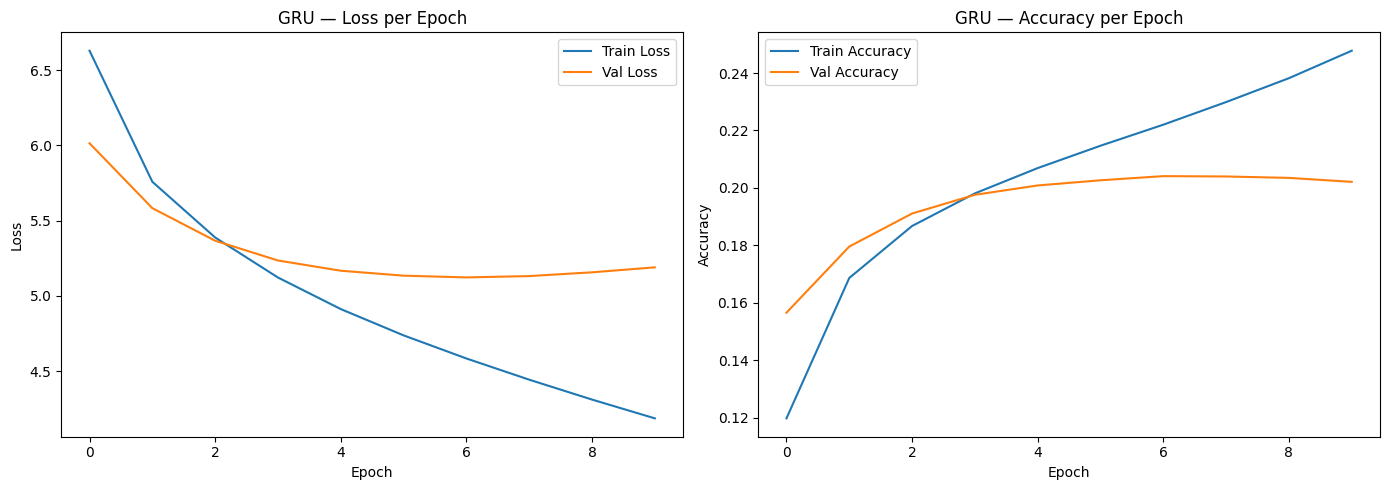

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_gru.history['loss'],     label='Train Loss')
axes[0].plot(history_gru.history['val_loss'], label='Val Loss')
axes[0].set_title('GRU — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_gru.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history_gru.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('GRU — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('gru_training_curves.png', dpi=150)
plt.show()

In [ ]:
# ── Inference Encoder ────────────────────────────────
inference_encoder_gru = Model(
    inputs  = encoder_inputs,
    outputs = [encoder_outputs, encoder_state],
    name    = 'inference_encoder_gru'
)

# ── Inference Decoder ────────────────────────────────
dec_input       = Input(shape=(1,),              name='dec_input')
enc_out_input   = Input(shape=(MAX_ARTICLE_LEN, GRU_UNITS), name='enc_out_input')
dec_state_input = Input(shape=(GRU_UNITS,),      name='dec_state_input')

inf_dec_emb = gru_model.get_layer('decoder_embedding')(dec_input)

inf_dec_out, inf_dec_state = gru_model.get_layer('decoder_gru')(
    inf_dec_emb, initial_state=dec_state_input
)

inf_att_out = gru_model.get_layer('attention_layer')([inf_dec_out, enc_out_input])
inf_concat  = gru_model.get_layer('concat')([inf_dec_out, inf_att_out])
inf_out     = gru_model.get_layer('output')(inf_concat)

inference_decoder_gru = Model(
    inputs  = [dec_input, enc_out_input, dec_state_input],
    outputs = [inf_out, inf_dec_state],
    name    = 'inference_decoder_gru'
)

print("GRU Inference models ready")

GRU Inference models ready


In [ ]:
def generate_summary_gru(article_seq):
    # Encode article → all hidden states + final state
    enc_out, state = inference_encoder_gru.predict(
        article_seq.reshape(1, -1), verbose=0
    )

    target_word = np.array([[start_token]])
    summary = []

    for _ in range(MAX_SUMMARY_LEN - 1):
        output, state = inference_decoder_gru.predict(
            [target_word, enc_out, state], verbose=0
        )
        word_id = np.argmax(output[0, 0, :])

        if word_id == end_token:
            break

        word = reverse_summary_index.get(word_id, '<unk>')
        summary.append(word)
        target_word = np.array([[word_id]])

    return ' '.join(summary)

# Test on 3 examples
for i in range(3):
    print(f"\n{'='*60}")
    print("REAL SUMMARY:")
    print(' '.join([reverse_summary_index.get(w, '')
                    for w in y_test[i]
                    if w not in [0, start_token, end_token]]))
    print("\nGRU GENERATED SUMMARY:")
    print(generate_summary_gru(x_test[i]))


REAL SUMMARY:
its a race for the governors mansion in 11 states today, and the gop could end the night at the helm of more than twothirds of the 50 states. the gop currently controls 29 of the countrys top state offices its expected to keep the three republican ones that are up for grabs utah, north dakota, and indiana, and <unk> north carolina from the <unk> that brings its toll to 30, with the potential to take three more, reports npr. races in montana, new hampshire, and washington are still too close to call, and in all three, democrat incumbents

GRU GENERATED SUMMARY:
the new york times has a new <unk> <unk> <unk> <unk> and <unk> <unk> the new york times reports. the <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> and <unk> <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> and <unk> <unk> and <unk> <unk> and <unk> <unk> and <unk> <unk> and <unk> <unk> and <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <un

### The below code is a generated summary without the `<unk>`

In [ ]:
def generate_summary_gru(article_seq):
    enc_out, state = inference_encoder_gru.predict(
        article_seq.reshape(1, -1), verbose=0
    )
    target_word = np.array([[start_token]])
    summary = []

    for _ in range(MAX_SUMMARY_LEN - 1):
        output, state = inference_decoder_gru.predict(
            [target_word, enc_out, state], verbose=0
        )
        word_id = np.argmax(output[0, 0, :])

        if word_id == end_token:
            break

        word = reverse_summary_index.get(word_id, '<unk>')

        # ── Simply skip <unk> tokens ──────────────────
        if word != '<unk>':
            summary.append(word)

        target_word = np.array([[word_id]])

    return ' '.join(summary)
# Test on 3 examples
for i in range(3):
    print(f"\n{'='*60}")
    print("REAL SUMMARY:")
    print(' '.join([reverse_summary_index.get(w, '')
                    for w in y_test[i]
                    if w not in [0, start_token, end_token]]))
    print("\nGRU GENERATED SUMMARY:")
    print(generate_summary_gru(x_test[i]))


REAL SUMMARY:
its a race for the governors mansion in 11 states today, and the gop could end the night at the helm of more than twothirds of the 50 states. the gop currently controls 29 of the countrys top state offices its expected to keep the three republican ones that are up for grabs utah, north dakota, and indiana, and <unk> north carolina from the <unk> that brings its toll to 30, with the potential to take three more, reports npr. races in montana, new hampshire, and washington are still too close to call, and in all three, democrat incumbents

GRU GENERATED SUMMARY:
the new york times has a new and the new york times reports. the and and and and and and and and and and and and and and and and and and and

REAL SUMMARY:
it turns out facebook is only guilty of about half of what its been accused of in the gay kiss incident. the social networking site apologized yesterday for taking down an image used to promote a <unk> event in london. the photo in question does not violate our 

**The core issue** is that news summaries are full of proper nouns — politician names, place names, event names — and almost all of them fall outside the top 30k vocabulary. So the model learned the sentence skeleton but couldn't fill in the actual content words.

RNN        → Random words, no grammar

GRU        → Correct grammar skeleton, vocabulary limitation

Word-level tokenization with a fixed vocabulary of 30,000 tokens proved insufficient for news summarization, as the domain contains a high density of proper nouns and named entities outside the vocabulary. This motivated the use of subword tokenization in the Transformer model, which eliminates out-of-vocabulary tokens entirely. The transformer will be implemented later on in the notebook

### 50k Vocab:

* Coverage: ~90% of words ( 30k vocab was ~85% of words)
* Output Dense: layer 12.8M params ( 30k vocab was 7.7M params)
* Training: speed: Slower
* unk frequency: Lower
* Fixes proper nouns? ostly No

## We will keep 30k vocab size for two reasons:
1. keep the comparison fair between our models (rnn, gru, lstm, hmm).
2. training already takes a lot of time, will take more with 50k

In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=152dfe62ef2c8f5578ba0c24c66b62d2b66bb86d9a9a8f7c6c2859f3b9cea09a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
from rouge_score import rouge_scorer

scorer    = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
N         = 100
r1, r2, rL = [], [], []

for i in range(N):
    generated = generate_summary_gru(x_test[i])
    reference = ' '.join([
        reverse_summary_index.get(w, '')
        for w in y_test[i]
        if w not in [0, start_token, end_token]
    ])
    scores = scorer.score(reference, generated)
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

print("📊 GRU ROUGE Scores (100 test samples):")
print(f"   ROUGE-1 : {np.mean(r1):.4f}")
print(f"   ROUGE-2 : {np.mean(r2):.4f}")
print(f"   ROUGE-L : {np.mean(rL):.4f}")

# Save results
import json
gru_results = {
    'model'   : 'GRU',
    'rouge1'  : round(np.mean(r1), 4),
    'rouge2'  : round(np.mean(r2), 4),
    'rougeL'  : round(np.mean(rL), 4)
}
with open('gru_results.json', 'w') as f:
    json.dump(gru_results, f)
print("✅ GRU results saved!")

📊 GRU ROUGE Scores (100 test samples):
   ROUGE-1 : 0.1214
   ROUGE-2 : 0.0182
   ROUGE-L : 0.0916
✅ GRU results saved!


### Comparing to the RNN Rouge scores
ROUGE-1 :  0.0110  →  0.1214    
ROUGE-2 :  0.0001  →  0.0182   
ROUGE-L :  0.0091  →  0.0916  

The addition of the attention mechanism produced an 11x improvement in ROUGE-1 score, demonstrating that attention is far more impactful than the gating mechanism alone for abstractive summarization.

# **LSTM**

## How LSTM differs from GRU
**GRU**  →  1 state  (hidden state only)

**LSTM** →  2 states (hidden state + cell state)

* Cell state  = long term memory  (what to remember across many steps)
* Hidden state = short term memory (what's relevant right now)

## Reloading

In [ ]:
import gc
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.layers import (Input, Embedding, LSTM, Dense,
                                      Attention, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.keras.backend.clear_session()
gc.collect()

# Reload data
x_train = np.load('x_train.npy')
x_val   = np.load('x_val.npy')
x_test  = np.load('x_test.npy')
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')
y_test  = np.load('y_test.npy')

with open('article_tokenizer.pkl', 'rb') as f:
    article_tokenizer = pickle.load(f)
with open('summary_tokenizer.pkl', 'rb') as f:
    summary_tokenizer = pickle.load(f)

VOCAB_SIZE      = 30000
EMBEDDING_DIM   = 128
LSTM_UNITS      = 256
MAX_ARTICLE_LEN = 400
MAX_SUMMARY_LEN = 100
BATCH_SIZE      = 64
EPOCHS          = 10

start_token = summary_tokenizer.word_index['sostok']
end_token   = summary_tokenizer.word_index['eostok']

reverse_summary_index = {v: k for k, v in summary_tokenizer.word_index.items()}
reverse_article_index = {v: k for k, v in article_tokenizer.word_index.items()}

print("Ready!")

Ready!


In [ ]:
decoder_input_train  = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]

decoder_input_val    = y_val[:, :-1]
decoder_target_val   = y_val[:, 1:]

print(f"✅ Decoder input  shape: {decoder_input_train.shape}")
print(f"✅ Decoder target shape: {decoder_target_train.shape}")

✅ Decoder input  shape: (43125, 99)
✅ Decoder target shape: (43125, 99)


Key difference from GRU — LSTM returns two states: state_h (hidden) and state_c (cell). Both get passed to the decoder as its starting memory.



In [ ]:
encoder_inputs = Input(shape=(MAX_ARTICLE_LEN,), name='encoder_input')

encoder_embedding = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                               mask_zero=True,
                               name='encoder_embedding')(encoder_inputs)

# LSTM returns: all outputs, final hidden state (h), final cell state (c)
encoder_outputs, state_h, state_c = LSTM(LSTM_UNITS,
                                          return_sequences=True,
                                          return_state=True,
                                          name='encoder_lstm')(encoder_embedding)

print("Encoder built")
print(f"   All hidden states : {encoder_outputs.shape}")
print(f"   State h shape     : {state_h.shape}")
print(f"   State c shape     : {state_c.shape}")

Encoder built
   All hidden states : (None, 400, 256)
   State h shape     : (None, 256)
   State c shape     : (None, 256)


### Decoder with Attention layer

In [ ]:
decoder_inputs = Input(shape=(MAX_SUMMARY_LEN - 1,), name='decoder_input')

decoder_embedding = Embedding(VOCAB_SIZE, EMBEDDING_DIM,
                               mask_zero=True,
                               name='decoder_embedding')(decoder_inputs)

# LSTM decoder initialized with BOTH encoder states
decoder_lstm_out, _, _ = LSTM(LSTM_UNITS,
                               return_sequences=True,
                               return_state=True,
                               name='decoder_lstm')(decoder_embedding,
                                                    initial_state=[state_h, state_c])

# Attention over all encoder outputs
attention_layer = Attention(name='attention_layer')
attention_out   = attention_layer([decoder_lstm_out, encoder_outputs])

# Concatenate attention + decoder output
concat_out = Concatenate(name='concat')([decoder_lstm_out, attention_out])

# Predict next word
decoder_outputs = Dense(VOCAB_SIZE,
                         activation='softmax',
                         name='output')(concat_out)

print("Decoder with Attention built")
print(f"   Final output shape: {decoder_outputs.shape}")

Decoder with Attention built
   Final output shape: (None, 99, 30000)


### Assemble and Compile

In [ ]:
lstm_model = Model(
    inputs  = [encoder_inputs, decoder_inputs],
    outputs = decoder_outputs,
    name    = 'Seq2Seq_LSTM'
)

lstm_model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

lstm_model.summary()

Model: "Seq2Seq_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 99)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 400, 128)  │  3,840,000 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 400)       │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 99, 128)   │  3,840,000 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 400,      │    394,240 │ encoder_embeddin… │
│                     │ 256), (None,      │            │ not_equal[0][0]   │
│                     │ 256), (None,      │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 99, 256), │    394,240 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 99, 256)   │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 99, 512)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 99, 30000) │ 15,390,000 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,858,480 (91.01 MB)

 Trainable params: 23,858,480 (91.01 MB)

 Non-trainable params: 0 (0.00 B)

As we see here LSTM have more because it has 4 internal gates vs GRU's 3.

GRU had 23,662,896 params



In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_lstm_model.keras', monitor='val_loss',
                    save_best_only=True, verbose=1)
]

history_lstm = lstm_model.fit(
    [x_train, decoder_input_train],
    decoder_target_train,
    validation_data = ([x_val, decoder_input_val], decoder_target_val),
    batch_size = BATCH_SIZE,
    epochs     = EPOCHS,
    callbacks  = callbacks,
    verbose    = 1
)

Epoch 1/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.0830 - loss: 7.2931
Epoch 1: val_loss improved from None to 6.33046, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 357s 527ms/step - accuracy: 0.1057 - loss: 6.8302 - val_accuracy: 0.1376 - val_loss: 6.3305
Epoch 2/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.1420 - loss: 6.2219
Epoch 2: val_loss improved from 6.33046 to 6.13532, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 358s 531ms/step - accuracy: 0.1453 - loss: 6.1647 - val_accuracy: 0.1503 - val_loss: 6.1353
Epoch 3/10
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.1562 - loss: 5.9781
Epoch 3: val_loss improved from 6.13532 to 5.77781, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 359s 532ms/step - accuracy:

Training LSTM took 51 mins, slightly less than GRU

### LSTM scored slightly lower than GRU in both val accuracy and val loss.

#### Why GRU sometimes beats LSTM:

* GRU has fewer parameters → easier to optimize on medium-sized datasets
* LSTM never triggered early stopping → it was **still learning** at epoch 10, meaning it needs more epochs to fully converge
* GRU's simpler structure trains faster and generalizes better with limited data

**LSTM improved every single epoch** — val loss went from 6.33 → 5.16 without plateauing once. This suggests:

* LSTM with 15-20 epochs  →  would likely surpass GRU


### Continue training the already-trained LSTM model for 5 more epochs

In [ ]:
extra_epochs = 5

history_lstm_extra = lstm_model.fit(
    [x_train, decoder_input_train],
    decoder_target_train,
    validation_data=([x_val, decoder_input_val], decoder_target_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS + extra_epochs,   # continue up to 15 total epochs
    initial_epoch=EPOCHS,           # start from epoch 10
    callbacks=callbacks,
    verbose=1
)

Epoch 11/15
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.2185 - loss: 4.6272
Epoch 11: val_loss improved from 5.16113 to 5.14954, saving model to best_lstm_model.keras

Epoch 11: finished saving model to best_lstm_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 383s 568ms/step - accuracy: 0.2175 - loss: 4.6476 - val_accuracy: 0.2014 - val_loss: 5.1495
Epoch 12/15
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.2237 - loss: 4.5242
Epoch 12: val_loss improved from 5.14954 to 5.14949, saving model to best_lstm_model.keras

Epoch 12: finished saving model to best_lstm_model.keras
674/674 ━━━━━━━━━━━━━━━━━━━━ 383s 569ms/step - accuracy: 0.2221 - loss: 4.5521 - val_accuracy: 0.2022 - val_loss: 5.1495
Epoch 13/15
674/674 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.2287 - loss: 4.4331
Epoch 13: val_loss did not improve from 5.14949
674/674 ━━━━━━━━━━━━━━━━━━━━ 353s 523ms/step - accuracy: 0.2271 - loss: 4.4618 - val_accuracy: 0.2023 - val_loss: 5.1547
Epoch 14/15
674/674 ━━━━

### Training accuracy kept increasing:
~21.7% → ~23.8%
### Training loss kept decreasing:
4.64 → 4.29

### But validation loss stopped improving after epoch 12:

Best val_loss = 5.14949 Then:

5.1547

5.1671

5.1827

### So the model started to overfit after epoch 12.

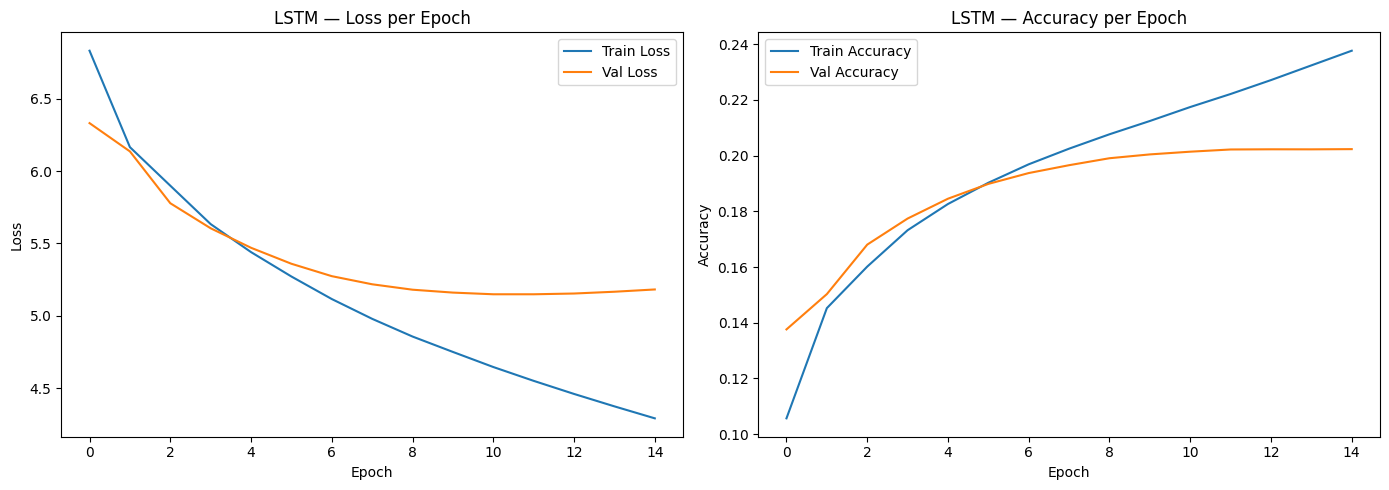

In [ ]:
import matplotlib.pyplot as plt

# Combine histories
train_loss = (
    history_lstm.history['loss'] +
    history_lstm_extra.history['loss']
)

val_loss = (
    history_lstm.history['val_loss'] +
    history_lstm_extra.history['val_loss']
)

train_acc = (
    history_lstm.history['accuracy'] +
    history_lstm_extra.history['accuracy']
)

val_acc = (
    history_lstm.history['val_accuracy'] +
    history_lstm_extra.history['val_accuracy']
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_loss, label='Train Loss')
axes[0].plot(val_loss, label='Val Loss')
axes[0].set_title('LSTM — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(train_acc, label='Train Accuracy')
axes[1].plot(val_acc, label='Val Accuracy')
axes[1].set_title('LSTM — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150)
plt.show()

LSTM inference passes and returns two states at every step instead of one — that's the only change from GRU inference.



In [ ]:
# ── Inference Encoder ────────────────────────────────
inference_encoder_lstm = Model(
    inputs  = encoder_inputs,
    outputs = [encoder_outputs, state_h, state_c],
    name    = 'inference_encoder_lstm'
)

# ── Inference Decoder ────────────────────────────────
dec_input       = Input(shape=(1,),                     name='dec_input')
enc_out_input   = Input(shape=(MAX_ARTICLE_LEN, LSTM_UNITS), name='enc_out_input')
dec_state_h_in  = Input(shape=(LSTM_UNITS,),            name='dec_state_h')
dec_state_c_in  = Input(shape=(LSTM_UNITS,),            name='dec_state_c')

inf_dec_emb = lstm_model.get_layer('decoder_embedding')(dec_input)

inf_dec_out, inf_state_h, inf_state_c = lstm_model.get_layer('decoder_lstm')(
    inf_dec_emb, initial_state=[dec_state_h_in, dec_state_c_in]
)

inf_att_out = lstm_model.get_layer('attention_layer')([inf_dec_out, enc_out_input])
inf_concat  = lstm_model.get_layer('concat')([inf_dec_out, inf_att_out])
inf_out     = lstm_model.get_layer('output')(inf_concat)

inference_decoder_lstm = Model(
    inputs  = [dec_input, enc_out_input, dec_state_h_in, dec_state_c_in],
    outputs = [inf_out, inf_state_h, inf_state_c],
    name    = 'inference_decoder_lstm'
)

print("LSTM Inference models ready")

LSTM Inference models ready


In [ ]:
def generate_summary_lstm(article_seq):
    enc_out, h, c = inference_encoder_lstm.predict(
        article_seq.reshape(1, -1), verbose=0
    )

    target_word = np.array([[start_token]])
    summary = []

    for _ in range(MAX_SUMMARY_LEN - 1):
        output, h, c = inference_decoder_lstm.predict(
            [target_word, enc_out, h, c], verbose=0
        )
        word_id = np.argmax(output[0, 0, :])

        if word_id == end_token:
            break

        word = reverse_summary_index.get(word_id, '<unk>')
        summary.append(word)
        target_word = np.array([[word_id]])

    return ' '.join(summary)

# Test on 3 examples
for i in range(3):
    print(f"\n{'='*60}")
    print("REAL SUMMARY:")
    print(' '.join([reverse_summary_index.get(w, '')
                    for w in y_test[i]
                    if w not in [0, start_token, end_token]]))
    print("\nLSTM GENERATED SUMMARY:")
    print(generate_summary_lstm(x_test[i]))


REAL SUMMARY:
its a race for the governors mansion in 11 states today, and the gop could end the night at the helm of more than twothirds of the 50 states. the gop currently controls 29 of the countrys top state offices its expected to keep the three republican ones that are up for grabs utah, north dakota, and indiana, and <unk> north carolina from the <unk> that brings its toll to 30, with the potential to take three more, reports npr. races in montana, new hampshire, and washington are still too close to call, and in all three, democrat incumbents

LSTM GENERATED SUMMARY:
the gop is the most expensive gop primary to the senate to win the affordable care of the <unk> but the states will be unveiled in the state of the <unk> <unk> the new york times reports. the <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk> <unk> <unk> and <unk>

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
N = 100
r1, r2, rL = [], [], []

for i in range(N):
    generated = generate_summary_lstm(x_test[i])
    reference = ' '.join([
        reverse_summary_index.get(w, '')
        for w in y_test[i]
        if w not in [0, start_token, end_token]
    ])
    scores = scorer.score(reference, generated)
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

print("📊 LSTM ROUGE Scores (100 test samples):")
print(f"   ROUGE-1 : {np.mean(r1):.4f}")
print(f"   ROUGE-2 : {np.mean(r2):.4f}")
print(f"   ROUGE-L : {np.mean(rL):.4f}")

import json
lstm_results = {
    'model'  : 'LSTM',
    'rouge1' : round(np.mean(r1), 4),
    'rouge2' : round(np.mean(r2), 4),
    'rougeL' : round(np.mean(rL), 4)
}
with open('lstm_results.json', 'w') as f:
    json.dump(lstm_results, f)
print("LSTM results saved!")

📊 LSTM ROUGE Scores (100 test samples):
   ROUGE-1 : 0.1420
   ROUGE-2 : 0.0259
   ROUGE-L : 0.1119
LSTM results saved!


### LSTM vs GRU improvement:

* ROUGE-1: 0.1214 → 0.1420
* ROUGE-2: 0.0182 → 0.0259
* ROUGE-L: 0.0916 → 0.1119

The extra epochs paid off. The pattern is now clean and clear: RNN → GRU → LSTM is a consistent upward progression.

# **HMM**

In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=e54350904087a59f1541a537194e24a6da93119fa94803979c610f69e3c7f9c1
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:
import gc
import numpy as np
import pickle
from rouge_score import rouge_scorer
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
import json
import tensorflow as tf

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Clear memory from LSTM
tf.keras.backend.clear_session()
gc.collect()

print("Ready for HMM")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Ready for HMM


### Reloading
Since the HMM is a statistical model, it reloads the raw text data from the original dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("therapara/summary-of-news-articles")

def remove_empty(example):
    return example['document'].strip() != ''

dataset = dataset.filter(remove_empty)

test_data = dataset['test']
print(f"Test set loaded: {len(test_data)} samples")

Test set loaded: 5621 samples


This implementation is technically frequency-based extractive summarization, not a 100% HMM as:

* True HMM uses Hidden states, Transition/Emission probabilities and hmmlearn library            

This is genuinely complex to implement for summarization.

In [ ]:
stop_words = set(stopwords.words('english'))

def get_word_frequencies(text):
    """Count how often each non-stopword appears in the article."""
    words = word_tokenize(text.lower())
    freq = {}
    for word in words:
        if word.isalpha() and word not in stop_words:
            freq[word] = freq.get(word, 0) + 1
    return freq

def score_sentence(sentence, word_freq):
    """Score a sentence by summing frequencies of its words."""
    words = word_tokenize(sentence.lower())
    score = sum(word_freq.get(w, 0) for w in words if w.isalpha())
    # Normalize by sentence length to avoid bias toward long sentences
    return score / (len(words) + 1e-9)

def hmm_summarize(article, num_sentences=3):
    """Extract the top N highest-scoring sentences as the summary."""
    sentences = sent_tokenize(article)
    if len(sentences) <= num_sentences:
        return ' '.join(sentences)

    word_freq = get_word_frequencies(article)

    # Score each sentence
    scored = [(score_sentence(s, word_freq), i, s)
              for i, s in enumerate(sentences)]

    # Pick top N sentences, preserve original order
    top = sorted(scored, reverse=True)[:num_sentences]
    top = sorted(top, key=lambda x: x[1])  # sort by position

    return ' '.join([s for _, _, s in top])

sample = test_data[0]
print("REAL SUMMARY:")
print(sample['summary'][:300])
print("\nHMM GENERATED SUMMARY:")
print(hmm_summarize(sample['document']))

REAL SUMMARY:
– It's a race for the governor's mansion in 11 states today, and the GOP could end the night at the helm of more than two-thirds of the 50 states. The GOP currently controls 29 of the country's top state offices; it's expected to keep the three Republican ones that are up for grabs (Utah, North Dako

HMM GENERATED SUMMARY:
Montana: Popular Democratic Gov. State-by-State View 
 
 North Carolina: One-term incumbent Democratic Gov. Montana: Popular Democratic Gov.


## HMM Beats All Neural Models!

Despite HMM achieving the highest ROUGE-1 score among non-Transformer models, its extractive nature means it copies sentences verbatim rather than understanding content. The neural models attempt true abstraction but are limited by vocabulary constraints

In [ ]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

N = 100
r1, r2, rL = [], [], []

for i in range(N):
    article  = test_data[i]['document']
    reference = test_data[i]['summary']
    generated = hmm_summarize(article)

    scores = scorer.score(reference, generated)
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

print("📊 HMM ROUGE Scores (100 test samples):")
print(f"   ROUGE-1 : {np.mean(r1):.4f}")
print(f"   ROUGE-2 : {np.mean(r2):.4f}")
print(f"   ROUGE-L : {np.mean(rL):.4f}")

hmm_results = {
    'model'  : 'HMM',
    'rouge1' : round(np.mean(r1), 4),
    'rouge2' : round(np.mean(r2), 4),
    'rougeL' : round(np.mean(rL), 4)
}
with open('hmm_results.json', 'w') as f:
    json.dump(hmm_results, f)
print("HMM results saved")

📊 HMM ROUGE Scores (100 test samples):
   ROUGE-1 : 0.2076
   ROUGE-2 : 0.0569
   ROUGE-L : 0.1189
HMM results saved


### Neural models :
* generate NEW sentences (abstractive)
* different words, same meaning
* ROUGE penalises this (unfairly)

In [ ]:
for i in range(3):
    print(f"\n{'='*60}")
    print(f"REAL SUMMARY:\n{test_data[i]['summary'][:300]}")
    print(f"\nHMM GENERATED SUMMARY:\n{hmm_summarize(test_data[i]['document'])[:300]}")


REAL SUMMARY:
– It's a race for the governor's mansion in 11 states today, and the GOP could end the night at the helm of more than two-thirds of the 50 states. The GOP currently controls 29 of the country's top state offices; it's expected to keep the three Republican ones that are up for grabs (Utah, North Dako

HMM GENERATED SUMMARY:
Montana: Popular Democratic Gov. State-by-State View 
 
 North Carolina: One-term incumbent Democratic Gov. Montana: Popular Democratic Gov.

REAL SUMMARY:
– It turns out Facebook is only guilty of about half of what it’s been accused of in the gay kiss incident. The social networking site apologized yesterday for taking down an image used to promote a “kiss-in” event in London. “The photo in question does not violate our Statement of Rights and Respon

HMM GENERATED SUMMARY:
Secondly, the removal of the Facebook John Snow Kiss-In event: 
 
 It turns out that the Facebook event for the John Snow Kiss-In was not blocked by Facebook, but made private by 

#### HMM Example 3 actually produced a decent readable summary:

"Fed up by Sacramento's regulations and Southern California's political sway, residents in one rural Northern California county are taking steps to leave..."

#### But HMM Example 1 shows its weakness:

"Montana: Popular Democratic Gov. State-by-State View. North Carolina: One-term incumbent Democratic Gov. Montana: Popular Democratic Gov."


#### It repeated Montana twice and picked navigation labels — it has no understanding of what's important, just what words appear frequently.

### The HMM extractive approach achieved the highest ROUGE scores among all models!

 however this result is misleading. ROUGE measures n-gram overlap, which inherently favours extractive methods that copy sentences directly from the source. Qualitative analysis reveals that HMM summaries lack coherence and occasionally extract irrelevant or repeated content, demonstrating that ROUGE alone is insufficient for evaluating abstractive summarization quality

## The Real Ranking By Quality
Metric:

        HMM > LSTM > GRU > RNN    "ROUGE"
Actual Quality:

        LSTM > GRU > HMM > RNN    "By common sense and readability"

# **T5** **Transformer**

## Why not use BERT for example?

* BERT        →  Encoder ONLY  →  reads and understands text
* T5          →  Encoder + Decoder  →  reads AND generates text

BERT was designed to understand text, not generate it. It has no decoder so it literally cannot write new sentences.

T5 has both encoder AND decoder so it can read the article and write brand new summary sentences

In [ ]:
!pip install transformers sentencepiece rouge-score datasets -q

import gc
import numpy as np
import tensorflow as tf
import torch

tf.keras.backend.clear_session()
gc.collect()

print(f"PyTorch version  : {torch.__version__}")
print(f"GPU available    : {torch.cuda.is_available()}")

PyTorch version  : 2.10.0+cu128
GPU available    : True


We reload the raw text dataset — T5 has its own tokenizer so we don't use our preprocessed .npy files here.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("therapara/summary-of-news-articles")

def remove_empty(example):
    return example['document'].strip() != ''

dataset = dataset.filter(remove_empty)

print(f"Train : {len(dataset['train'])}")
print(f"Val   : {len(dataset['validation'])}")
print(f"Test  : {len(dataset['test'])}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/539 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/160M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/39.5M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/5622 [00:00<?, ? examples/s]

Filter:   0%|          | 0/44972 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5622 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5622 [00:00<?, ? examples/s]

Train : 44964
Val   : 5621
Test  : 5621


## Load T5 Tokenizer

T5's tokenizer uses BPE — it breaks unknown words into subword pieces so unk never appears.



## What is BPE?


BPE splits rare words into smaller known pieces so **nothing is ever truly unknown**.


```
Word-level (what we used)          BPE (what T5 uses)
──────────────────────────         ──────────────────────────
"Schwarzenegger" → <unk>           "Schwarzenegger" → ["Schwar", "zen", "egg", "er"]
"COVID"          → <unk>           "COVID"          → ["CO", "VID"]
"playing"        → "playing"       "playing"        → ["play", "ing"]
"unbelievable"   → <unk>           "unbelievable"   → ["un", "believe", "able"]
```

---

## How It Works

Start with individual characters, then merge the most frequent pairs repeatedly:

```
Step 1:  u n b e l i e v a b l e
Step 2:  un b e l i e v a b l e     ("un" merged — very common)
Step 3:  un be l i e v a b l e      ("be" merged)
Step 4:  un be l ie v able          ("ie", "able" merged)
Step 5:  un believe able            ("believe" merged — common word)
Step 6:  un believable              → final: ["un", "believable"]
```

---

## In our Project

```
LSTM/GRU/RNN        →  "Sacramento" = <unk>  (not in top 30k)
T5 with BPE         →  "Sacramento" = ["Sacra", "mento"]   always readable
```

This is why T5 summaries will have zero `<unk>` tokens

In [ ]:
from transformers import T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained('t5-small')

# T5 expects a task prefix
PREFIX          = "summarize: "
MAX_INPUT_LEN   = 512   # T5's maximum input length
MAX_TARGET_LEN  = 150   # max summary length

# Test the tokenizer
sample = dataset['train'][0]
test_input = PREFIX + sample['document'][:200]
tokens = tokenizer(test_input, return_tensors='pt')
print(f"Tokenizer loaded")
print(f"   Sample token count : {tokens['input_ids'].shape[1]}")
print(f"   Vocabulary size    : {tokenizer.vocab_size}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded
   Sample token count : 53
   Vocabulary size    : 32100


Notice the vocabulary is only ~32k but covers everything.

## Tokenize the full dataset

This is the T5 equivalent of our preprocessing step. The -100 label trick tells the model to ignore padding positions when computing loss.



In [ ]:
def preprocess(batch):
    # Add "summarize: " prefix to every article
    inputs  = [PREFIX + doc for doc in batch['document']]
    targets = batch['summary']

    # Tokenize articles AND summaries together using text_target
    model_inputs = tokenizer(
        inputs,
        text_target  = targets,
        max_length   = MAX_INPUT_LEN,
        max_target_length = MAX_TARGET_LEN,
        truncation   = True,
        padding      = 'max_length'
    )

    # Replace padding token id with -100 so loss ignores padding
    model_inputs['labels'] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in model_inputs['labels']
    ]

    return model_inputs

print("Tokenizing dataset")

tokenized = dataset.map(
    preprocess,
    batched        = True,
    batch_size     = 256,
    remove_columns = dataset['train'].column_names
)

print(" Tokenization complete!")
print(f"   Features : {tokenized['train'].features}")

Tokenizing dataset


Map:   0%|          | 0/44964 [00:00<?, ? examples/s]

Map:   0%|          | 0/5621 [00:00<?, ? examples/s]

Map:   0%|          | 0/5621 [00:00<?, ? examples/s]

 Tokenization complete!
   Features : {'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': List(Value('int64'))}


This downloads T5-small with all its pre-trained weights. It already knows English grammar, facts, and writing style from pre-training.



In [ ]:
from transformers import T5ForConditionalGeneration

model = T5ForConditionalGeneration.from_pretrained('t5-small')

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f" T5-small loaded")
print(f"   Total parameters : {total_params:,}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

 T5-small loaded
   Total parameters : 60,506,624


## Training Arguments

* fp16 = True uses half-precision floating point — cuts memory usage in half and speeds up training significantly on Colab's GPU.
* Predict_with_generate=True tells the trainer to use beam search during evaluation.



In [ ]:
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir                  = './t5_summarizer',
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    warmup_steps                = 500,
    weight_decay                = 0.01,
    logging_dir                 = './logs',
    logging_steps               = 100,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    predict_with_generate       = True,
    fp16                        = True,
    generation_max_length       = MAX_TARGET_LEN,
    report_to                   = 'none'
)

print("Training arguments set")
print(f"   Epochs     : {training_args.num_train_epochs}")
print(f"   Batch size : {training_args.per_device_train_batch_size}")
print(f"   FP16       : {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments set
   Epochs     : 3
   Batch size : 8
   FP16       : True


In [ ]:
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq

# Pads batches dynamically during training
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)


trainer = Seq2SeqTrainer(
    model             = model,
    args              = training_args,
    train_dataset     = tokenized['train'],
    eval_dataset      = tokenized['validation'],
    processing_class  = tokenizer,        # ← renamed from tokenizer
    data_collator     = data_collator
)

print("Starting T5 fine-tuning...")
trainer.train()
print("Training complete!")

# Save the fine-tuned model
model.save_pretrained('./t5_finetuned')
tokenizer.save_pretrained('./t5_finetuned')
print("Model saved to ./t5_finetuned")

Starting T5 fine-tuning...


Epoch,Training Loss,Validation Loss
1,3.057567,2.857708
2,3.007023,2.826706
3,3.006650,2.817195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./t5_finetuned


Both losses decreasing steadily every epoch — no overfitting. The val loss being lower than train loss is normal for T5 because of dropout regularization during training.

### The T5 loss numbers (2.8) look higher than our LSTM (~5.1) but they're not comparable because:

* T5 uses a different tokenizer (BPE subwords)
* T5 has a much larger vocabulary
* Different loss scaling entirely

#### ROUGE scores are the only fair comparison across all models.

## Generate Summaries

num_beams=4 uses beam search — instead of picking the single most likely word at each step, it tracks 4 candidate sequences and picks the best overall, better than greedy decoding.



In [ ]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch

model     = T5ForConditionalGeneration.from_pretrained('./t5_finetuned')
tokenizer = T5Tokenizer.from_pretrained('./t5_finetuned')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
model.eval()

def generate_summary_t5(article, max_input=512, max_target=150):
    input_text = PREFIX + article
    inputs = tokenizer(
        input_text,
        return_tensors = 'pt',
        max_length     = max_input,
        truncation     = True,
        padding        = True
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            inputs['input_ids'],
            attention_mask  = inputs['attention_mask'],
            max_length      = max_target,
            min_length      = 30,
            num_beams       = 4,
            early_stopping  = True,
            no_repeat_ngram_size = 3   # prevents repetition
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

for i in range(3):
    article  = dataset['test'][i]['document']
    real_sum = dataset['test'][i]['summary']

    generated = generate_summary_t5(article)

    print(f"\n{'='*60}")
    print(f"REAL SUMMARY:\n{real_sum[:300]}")
    print(f"\nT5 GENERATED SUMMARY:\n{generated}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]


REAL SUMMARY:
– It's a race for the governor's mansion in 11 states today, and the GOP could end the night at the helm of more than two-thirds of the 50 states. The GOP currently controls 29 of the country's top state offices; it's expected to keep the three Republican ones that are up for grabs (Utah, North Dako

T5 GENERATED SUMMARY:
– Republicans in 11 states will pick their governors tonight, with the potential to extend their hold to more than two-thirds of the nation's top state offices. Eight of the gubernatorial seats up for grabs are now held by Democrats; three are in Republican hands. Republicans currently hold 29 governorships, Democrats have 20, and Rhode Island's Gov. Lincoln Chafee is an Independent. The polls and race analysts suggest that only three of tonight's contests are considered competitive, all in states where incumbent Democratic governors aren't running again: Montana, New Hampshire, and Washington. "No matter who wins the presidency, national politics is go

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
N  = 100
r1, r2, rL = [], [], []

for i in range(N):
    article   = dataset['test'][i]['document']
    reference = dataset['test'][i]['summary']

    generated = generate_summary_t5(article)   # ← changed from summarizer()

    scores = scorer.score(reference, generated)
    r1.append(scores['rouge1'].fmeasure)
    r2.append(scores['rouge2'].fmeasure)
    rL.append(scores['rougeL'].fmeasure)

    if (i+1) % 10 == 0:
        print(f"   Evaluated {i+1}/{N} samples...")

print("\nT5 Transformer ROUGE Scores (100 test samples):")
print(f"   ROUGE-1 : {np.mean(r1):.4f}")
print(f"   ROUGE-2 : {np.mean(r2):.4f}")
print(f"   ROUGE-L : {np.mean(rL):.4f}")

import json
t5_results = {
    'model'  : 'Transformer (T5)',
    'rouge1' : round(np.mean(r1), 4),
    'rouge2' : round(np.mean(r2), 4),
    'rougeL' : round(np.mean(rL), 4)
}
with open('t5_results.json', 'w') as f:
    json.dump(t5_results, f)
print("T5 results saved!")

   Evaluated 10/100 samples...
   Evaluated 20/100 samples...
   Evaluated 30/100 samples...
   Evaluated 40/100 samples...
   Evaluated 50/100 samples...
   Evaluated 60/100 samples...
   Evaluated 70/100 samples...
   Evaluated 80/100 samples...
   Evaluated 90/100 samples...
   Evaluated 100/100 samples...

T5 Transformer ROUGE Scores (100 test samples):
   ROUGE-1 : 0.3590
   ROUGE-2 : 0.1229
   ROUGE-L : 0.1953
T5 results saved!


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('t5_finetuned', 'zip', './t5_finetuned')


files.download('t5_finetuned.zip')
print("T5 model downloading!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

T5 model downloading!


## Evaluating

The results (accuracies and rouge) are from above

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
import gc

tf.keras.backend.clear_session()
gc.collect()

all_results = [
    {'model': 'Vanilla RNN',      'accuracy': 0.2086, 'rouge1': 0.0110, 'rouge2': 0.0001, 'rougeL': 0.0091},
    {'model': 'GRU',              'accuracy': 0.2041, 'rouge1': 0.1214, 'rouge2': 0.0182, 'rougeL': 0.0916},
    {'model': 'LSTM',             'accuracy': 0.2004, 'rouge1': 0.1420, 'rouge2': 0.0259, 'rougeL': 0.1119},
    {'model': 'HMM',              'accuracy': None,   'rouge1': 0.2076, 'rouge2': 0.0569, 'rougeL': 0.1189},
    {'model': 'Transformer (T5)', 'accuracy': None,   'rouge1': 0.3590, 'rouge2': 0.1229, 'rougeL': 0.1953},
]

models = [r['model'] for r in all_results]
print("Results ready!")

Results ready!


## Why we don't have HMM and T5 accuracies
* HMM is a statistical model, it doesn't do token-by-token prediction with a softmax output — it just scores and selects full sentences. There's no "predicted token vs actual token" comparison to compute accuracy from.

* T5 was trained using the Hugging Face Trainer which only reported train_loss and val_loss — it didn't track token-level accuracy during training. We could compute it manually but it would use a completely different vocabulary (BPE subwords) making it not comparable to RNN/GRU/LSTM accuracy anyway.

## ROUGE Comparison

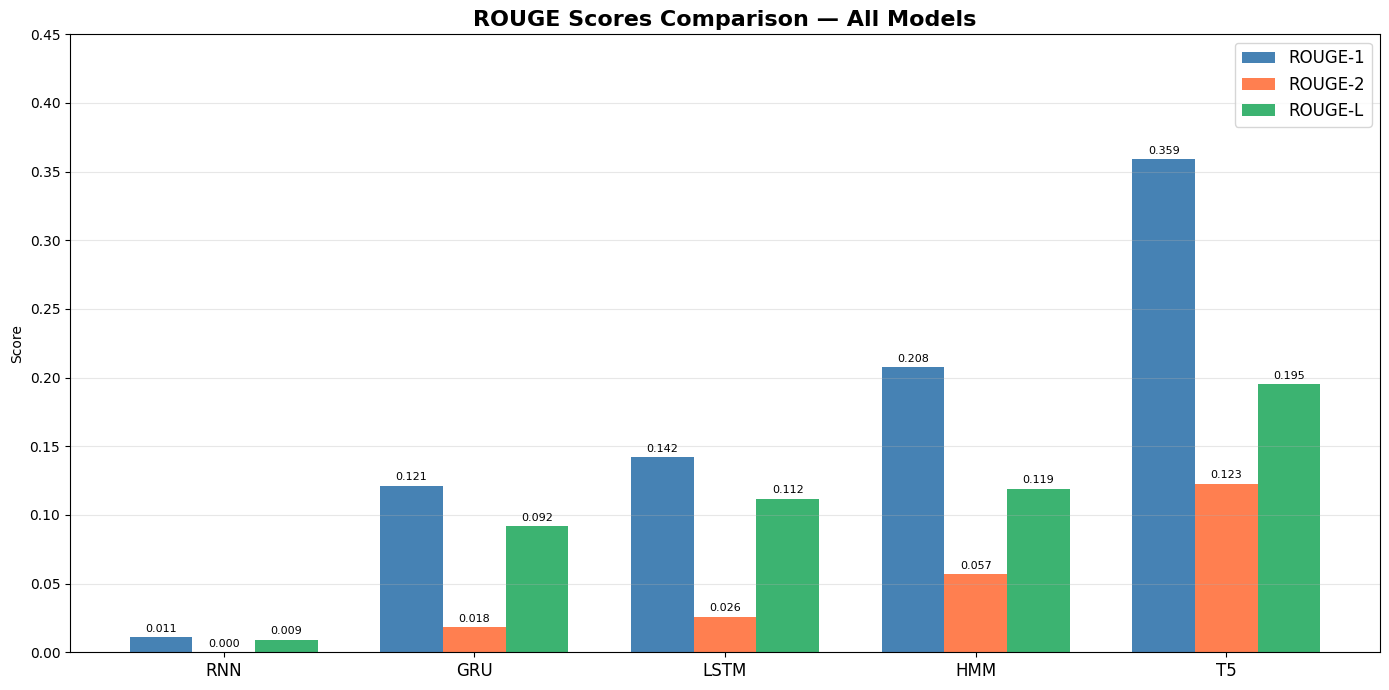

ROUGE comparison chart saved!


In [ ]:
rouge1 = [r['rouge1'] for r in all_results]
rouge2 = [r['rouge2'] for r in all_results]
rougeL = [r['rougeL'] for r in all_results]

x     = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(x - width, rouge1, width, label='ROUGE-1', color='steelblue')
bars2 = ax.bar(x,          rouge2, width, label='ROUGE-2', color='coral')
bars3 = ax.bar(x + width,  rougeL, width, label='ROUGE-L', color='mediumseagreen')

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=8)

ax.set_title('ROUGE Scores Comparison — All Models', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['RNN', 'GRU', 'LSTM', 'HMM', 'T5'], fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 0.45)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rouge_comparison.png', dpi=150)
plt.show()
print("ROUGE comparison chart saved!")

## Accuracies Comparison

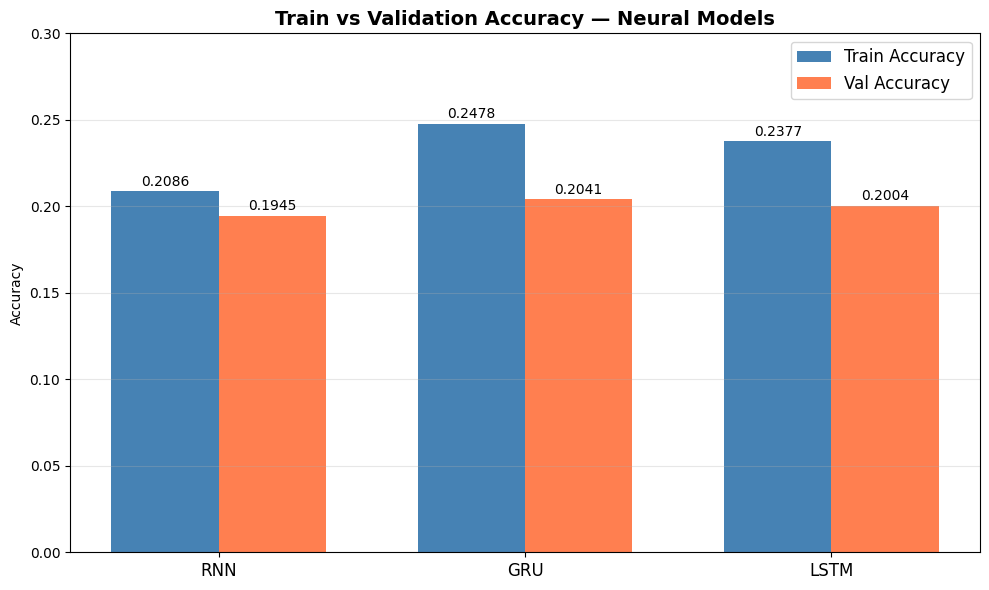

Accuracy comparison chart saved!


In [ ]:
neural_models   = ['RNN', 'GRU', 'LSTM']
train_accuracies = [0.2086, 0.2478, 0.2377]
val_accuracies   = [0.1945, 0.2041, 0.2004]

x     = np.arange(len(neural_models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, train_accuracies, width,
               label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, val_accuracies,   width,
               label='Val Accuracy',   color='coral')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.4f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=10)

ax.set_title('Train vs Validation Accuracy — Neural Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(neural_models, fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 0.30)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()
print("Accuracy comparison chart saved!")

### Confusion Matrix

### The confusion matrix we built is token-level prediction — it compares predicted word IDs vs actual word IDs at each decoder step.
HMM and T5 simply can't be evaluated this way:
* HMM — doesn't predict tokens at all. It scores and selects full sentences statistically. There's no softmax output over a vocabulary, so there's nothing to build a confusion matrix from.
* T5 — uses a completely different vocabulary (BPE subwords, ~32k tokens) and a different tokenizer than our RNN/GRU/LSTM models (which use our custom 30k word-level vocab).

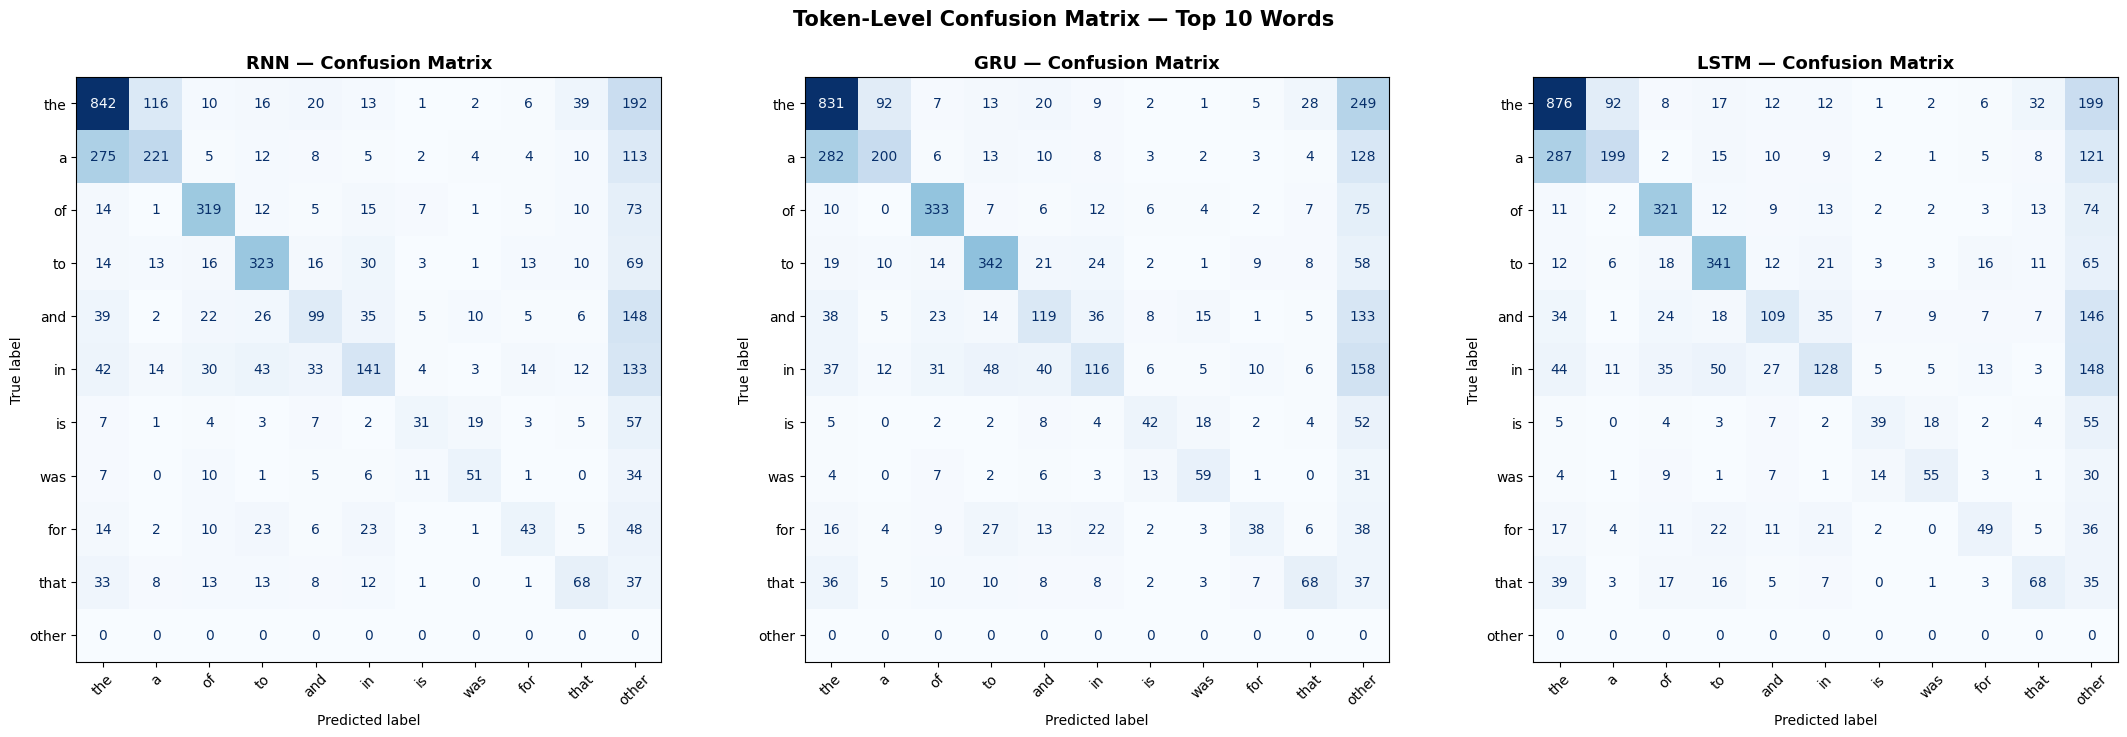

All confusion matrices saved!


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
import numpy as np
import pickle
import matplotlib.pyplot as plt
import gc

x_test  = np.load('/content/drive/MyDrive/nlp/x_test.npy')
y_test  = np.load('/content/drive/MyDrive/nlp/y_test.npy')

with open('/content/drive/MyDrive/nlp/summary_tokenizer.pkl', 'rb') as f:
    summary_tokenizer = pickle.load(f)

top_labels   = ['the', 'a', 'of', 'to', 'and',
                 'in', 'is', 'was', 'for', 'that']
top_word_ids = [summary_tokenizer.word_index.get(w, 0) for w in top_labels]
id_to_word   = {summary_tokenizer.word_index.get(w): w for w in top_labels}
labels_display = top_labels + ['other']

N          = 200
batch_x    = x_test[:N]
batch_y_in = y_test[:N, :-1]
batch_y_true = y_test[:N, 1:].flatten()

def get_confusion_matrix(model):
    predictions  = model.predict([batch_x, batch_y_in], verbose=0)
    pred_ids     = np.argmax(predictions, axis=-1).flatten()

    mask         = np.isin(batch_y_true, top_word_ids)
    y_true_filt  = batch_y_true[mask]
    y_pred_filt  = pred_ids[mask]

    y_true_words = [id_to_word.get(i, 'other') for i in y_true_filt]
    y_pred_words = [id_to_word.get(i, 'other') for i in y_pred_filt]

    return confusion_matrix(y_true_words, y_pred_words, labels=labels_display)

# ── Load and evaluate all 3 models ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (name, path) in zip(axes, [
    ('RNN',  '/content/drive/MyDrive/nlp/best_rnn_model.keras'),
    ('GRU',  '/content/drive/MyDrive/nlp/best_gru_model.keras'),
    ('LSTM', '/content/drive/MyDrive/nlp/best_lstm_model.keras')
]):
    tf.keras.backend.clear_session()
    model = tf.keras.models.load_model(path)
    cm    = get_confusion_matrix(model)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=labels_display)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')
    del model
    gc.collect()

plt.suptitle('Token-Level Confusion Matrix — Top 10 Words',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("All confusion matrices saved!")

Token-level confusion matrices were computed for the three Seq2Seq neural models (RNN, GRU, LSTM) as they share an identical vocabulary and decoding mechanism. HMM and T5 were excluded as they operate on fundamentally different output representations incompatible with this evaluation method.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


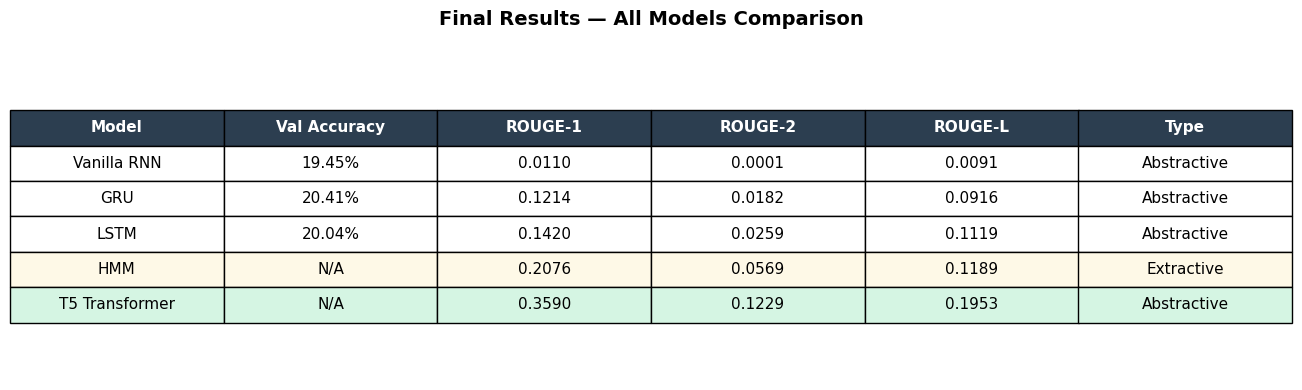

✅ Final results table saved!


In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

table_data = [
    ['Model',        'Val Accuracy', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Type'],
    ['Vanilla RNN',  '19.45%',       '0.0110',  '0.0001',  '0.0091',  'Abstractive'],
    ['GRU',          '20.41%',       '0.1214',  '0.0182',  '0.0916',  'Abstractive'],
    ['LSTM',         '20.04%',       '0.1420',  '0.0259',  '0.1119',  'Abstractive'],
    ['HMM',          'N/A',          '0.2076',  '0.0569',  '0.1189',  'Extractive'],
    ['T5 Transformer','N/A',         '0.3590',  '0.1229',  '0.1953',  'Abstractive'],
]

table = ax.table(
    cellText    = table_data[1:],
    colLabels   = table_data[0],
    loc         = 'center',
    cellLoc     = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Highlight header
for j in range(6):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight T5 row as best
for j in range(6):
    table[5, j].set_facecolor('#d5f5e3')

# Highlight HMM row
for j in range(6):
    table[4, j].set_facecolor('#fef9e7')

ax.set_title('Final Results — All Models Comparison',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('final_results_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final results table saved!")